In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [4]:
import zipfile

In [5]:
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/dataset/train.zip','r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [6]:
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/dataset/valid.zip','r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [32]:
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/dataset/test.zip','r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [8]:
# prompt: different class names

base_dir = '/tmp/train/'
class_names = os.listdir(base_dir)
print(class_names)


['acne', 'oil', 'dry']


In [9]:

from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
# Define the Sequential model
keras_model = Sequential()

# Add the pre-trained DenseNet169 model
pretrained_model = tf.keras.applications.DenseNet169(include_top=False,
                   input_shape=(640, 640, 3),
                   pooling='avg', weights='imagenet')

# Freeze the layers of the pre-trained model
for layer in pretrained_model.layers:
    layer.trainable = False

keras_model.add(pretrained_model)
keras_model.add(Flatten())

# Add a dense layer with dropout and batch normalization
keras_model.add(Dense(512, activation='relu'))
keras_model.add(BatchNormalization())
keras_model.add(Dropout(0.5))

# Add another dense layer
keras_model.add(Dense(256, activation='relu'))
keras_model.add(BatchNormalization())
keras_model.add(Dropout(0.5))

# Add the final classification layer
keras_model.add(Dense(3, activation='softmax'))

# Compile the model
keras_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Print the model summary
keras_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet169 (Functional)    (None, 1664)              12642880  
                                                                 
 module_wrapper (ModuleWrap  (None, 1664)              0         
 per)                                                            
                                                                 
 module_wrapper_1 (ModuleWr  (None, 512)               852480    
 apper)                                                          
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                        

In [10]:
keras_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet169 (Functional)    (None, 1664)              12642880  
                                                                 
 module_wrapper (ModuleWrap  (None, 1664)              0         
 per)                                                            
                                                                 
 module_wrapper_1 (ModuleWr  (None, 512)               852480    
 apper)                                                          
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                        

In [11]:
keras_model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data generators for training, validation, and test sets
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
        '/tmp/train/',
        target_size=(640, 640),
        batch_size=32,
        class_mode='categorical')

valid_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = valid_datagen.flow_from_directory(
        '/tmp/valid/',
        target_size=(640, 640),
        batch_size=32,
        class_mode='categorical')

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        '/tmp/test/',
        target_size=(640, 640),
        batch_size=32,
        class_mode='categorical')

# Fit the model using the generators
history = keras_model.fit(
      train_generator,
      steps_per_epoch=train_generator.samples/train_generator.batch_size,
      validation_data=validation_generator,
      validation_steps=validation_generator.samples/validation_generator.batch_size,
      epochs=20)

Found 603 images belonging to 3 classes.
Found 58 images belonging to 3 classes.
Found 28 images belonging to 3 classes.
Epoch 1/20
18/18 [==============================] - 21s 1s/step - loss: 0.0132 - accuracy: 0.9967 - val_loss: 0.2820 - val_accuracy: 0.9483
Epoch 2/20
18/18 [==============================] - 19s 1s/step - loss: 0.0129 - accuracy: 0.9967 - val_loss: 0.3048 - val_accuracy: 0.9310
Epoch 3/20
18/18 [==============================] - 19s 998ms/step - loss: 0.0215 - accuracy: 0.9917 - val_loss: 0.2541 - val_accuracy: 0.9483
Epoch 4/20
18/18 [==============================] - 19s 987ms/step - loss: 0.0120 - accuracy: 0.9950 - val_loss: 0.2799 - val_accuracy: 0.9138
Epoch 5/20
18/18 [==============================] - 19s 995ms/step - loss: 0.0109 - accuracy: 0.9967 - val_loss: 0.1689 - val_accuracy: 0.9310
Epoch 6/20
18/18 [==============================] - 20s 1s/step - loss: 0.0122 - accuracy: 0.9950 - val_loss: 0.2574 - val_accuracy: 0.8966
Epoch 7/20
18/18 [============

In [ ]:
test_loss, test_acc = keras_model.evaluate(test_generator, verbose=2)
print('\nTest accuracy:', test_acc)

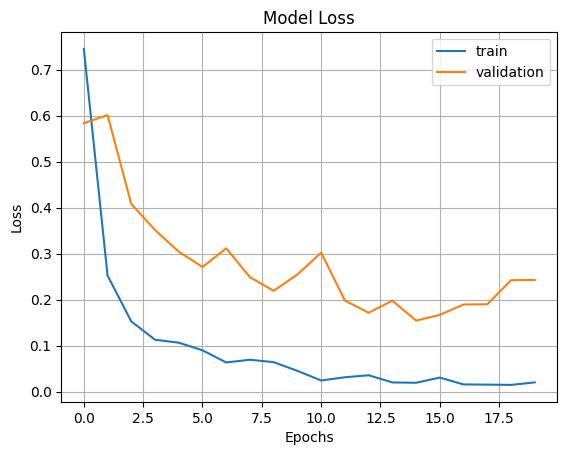

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [17]:
import math

# Evaluate the model using the test generator
steps = math.ceil(test_generator.samples / test_generator.batch_size)
test_loss, test_accuracy = keras_model.evaluate(test_generator, steps=steps)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on the test set
test_generator.reset()  # Reset the generator to start from the beginning
predictions = keras_model.predict(test_generator, steps=steps, verbose=1)

# Get the class indices and labels
class_indices = test_generator.class_indices
labels = list(class_indices.keys())

# Function to decode predictions
def decode_predictions(predictions, labels, top=5):
    decoded = []
    for pred in predictions:
        top_indices = pred.argsort()[-top:][::-1]
        top_labels = [labels[i] for i in top_indices]
        top_scores = [pred[i] for i in top_indices]
        decoded.append(list(zip(top_labels, top_scores)))
    return decoded

# Decode the predictions
decoded_predictions = decode_predictions(predictions, labels)

# Print the predictions for the first few test images
for i in range(min(len(decoded_predictions), 5)):
    print(f"Test Image {i+1}:")
    for label, score in decoded_predictions[i]:
        print(f"   Label: {label}, Confidence: {score:.4f}")


1/1 [==============================] - 1s 1s/step - loss: 0.0760 - accuracy: 0.9643
Test Accuracy: 0.9643
1/1 [==============================] - 3s 3s/step
Test Image 1:
   Label: oil, Confidence: 1.0000
   Label: dry, Confidence: 0.0000
   Label: acne, Confidence: 0.0000
Test Image 2:
   Label: dry, Confidence: 1.0000
   Label: acne, Confidence: 0.0000
   Label: oil, Confidence: 0.0000
Test Image 3:
   Label: dry, Confidence: 1.0000
   Label: oil, Confidence: 0.0000
   Label: acne, Confidence: 0.0000
Test Image 4:
   Label: oil, Confidence: 1.0000
   Label: dry, Confidence: 0.0000
   Label: acne, Confidence: 0.0000
Test Image 5:
   Label: acne, Confidence: 0.9997
   Label: oil, Confidence: 0.0003
   Label: dry, Confidence: 0.0000


1/1 [==============================] - 7s 7s/step
The image belongs to: acne with confidence: 0.9998


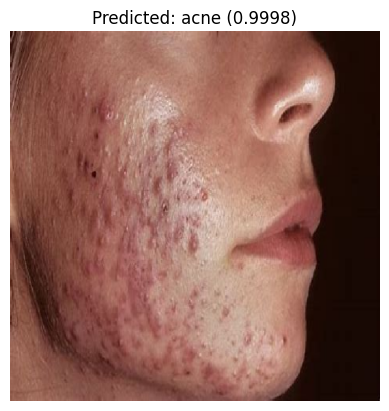

In [18]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Function to load and preprocess a single image
def load_and_preprocess_image(img_path, target_size=(640, 640)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale to [0, 1] if you used rescale=1./255 in ImageDataGenerator
    return img_array

# Function to predict the class of a single image
def predict_image_class(model, img_path, class_indices):
    # Load and preprocess the image
    img_array = load_and_preprocess_image(img_path)

    # Make prediction
    predictions = model.predict(img_array)

    # Get the class labels
    labels = list(class_indices.keys())

    # Decode the prediction
    top_index = np.argmax(predictions[0])
    top_label = labels[top_index]
    top_confidence = predictions[0][top_index]

    return top_label, top_confidence

# Assuming class indices from the test generator
class_indices = {'acne': 0, 'dry': 1, 'oily': 2}

# Path to the image you want to predict
test_image_path = '/content/drive/MyDrive/dataset/acne1.jpeg'  # Replace with your test image path

# Predict the class of the test image
predicted_label, confidence = predict_image_class(keras_model, test_image_path, class_indices)

# Print the prediction
print(f"The image belongs to: {predicted_label} with confidence: {confidence:.4f}")

# Optionally, display the image
img = image.load_img(test_image_path, target_size=(640, 640))
plt.imshow(img)
plt.title(f"Predicted: {predicted_label} ({confidence:.4f})")
plt.axis('off')
plt.show()


In [ ]:
import pandas as pd

In [20]:
df = pd.read_csv('/content/drive/MyDrive/dataset/result.csv')


In [21]:
df.columns

Index(['label', 'url', 'brand', 'name', 'price', 'skin type', 'spf', 'concern',
       'concern 2', 'concern 3', 'key ingredient', 'formulation'],
      dtype='object')

In [22]:
df['label'].value_counts()

label
face-moisturisers    300
cleanser             300
concealer            300
mask-and-peel        300
foundation           300
sunscreen            272
Name: count, dtype: int64

In [23]:
df['concern 2'].fillna('', inplace = True)
df['concern 3'].fillna('', inplace = True)
df['skin type'] = df['skin type'] + ',' + df['concern'] + ',' + df['concern 2'] + ',' + df['concern 3']


In [24]:
df.drop(columns=['concern','concern 2', 'concern 3', 'spf', 'key ingredient', 'formulation'], inplace = True)

In [25]:
df.columns

Index(['label', 'url', 'brand', 'name', 'price', 'skin type'], dtype='object')

In [26]:
df.isna().sum()

label          0
url            0
brand         46
name          46
price         46
skin type    619
dtype: int64

In [27]:
df.dropna(subset=['skin type'], inplace=True)

In [28]:
filtered_df = df[df['skin type'].str.contains('acne|oily|Oil Control|Dryness|dry|Excess Oil', case=False)]

In [29]:
filtered_df

,label,url,brand,name,price,skin type
2,face-moisturisers,https://www.myntra.com/face-moisturisers/nivea...,Nivea,Unisex Aloe Hydration Skin Cream 100 ml,₹ 92,"All,Dull Skin,Dryness,General Care"
9,face-moisturisers,https://www.myntra.com/face-moisturisers/nivea...,Nivea,Soft Light Moisturizer with Vitamin E 100ml,₹ 166,"All,General Care,Dryness,Softening and Smoothe..."
11,face-moisturisers,https://www.myntra.com/face-moisturisers/neutr...,Neutrogena,Hydro Boost Emulsion Face Moisturisers 50 g,₹ 1100,"Dry,General Care,,"
12,face-moisturisers,https://www.myntra.com/face-moisturisers/bewak...,BEWAKOOF COSMOS,Touch of Universe Face Moisturizer with Vitami...,₹ 174,"Normal,Dryness,Skin Inflammation,Sun Protection"
15,face-moisturisers,https://www.myntra.com/face-moisturisers/bioti...,Biotique,Bio Wheat Germ Youthful Nourishing Night Susta...,₹ 135,"All,Dryness,Deep Nourishment,Dryness"
...,...,...,...,...,...,...
1533,foundation,https://www.myntra.com/foundation-and-primer/m...,Miss Claire,Professional Stick Foundation - FS45,₹ 303,"All,Acne or Blemishes,,"
1542,foundation,https://www.myntra.com/foundation-and-primer/m...,Miss Claire,Professional Stick Foundation - 303,₹ 303,"All,Acne or Blemishes,,"
1555,foundation,https://www.myntra.com/foundation-and-primer/m...,Miss Claire,Professional Stick Foundation - FS28,₹ 303,"All,Acne or Blemishes,,"
1563,foundation,https://www.myntra.com/foundation-and-primer/m...,Miss Claire,Professional Stick Foundation - FS40,₹ 303,"All,Acne or Blemishes,,"


In [30]:
filtered_df['label'].value_counts()

label
cleanser             133
mask-and-peel        111
face-moisturisers     88
sunscreen             18
foundation             7
concealer              3
Name: count, dtype: int64

In [31]:
def recommend_products(skin_type, top_n=5):
    recommended_products = filtered_df[filtered_df['skin type'].str.contains(skin_type, case=False)]
    top_recommended_products = recommended_products.head(top_n)
    return top_recommended_products.to_dict(orient='records')
# Recommend products based on the predicted skin type
recommended_products = recommend_products(predicted_label)
print(recommended_products)

[{'label': 'face-moisturisers', 'url': 'https://www.myntra.com/face-moisturisers/plum/plum-green-tea-range-mattifying-sustainable-moisturizer-50ml/1460744/buy', 'brand': 'Plum', 'name': 'Green Tea Range Mattifying Sustainable Moisturizer 50ml', 'price': '₹ 413', 'skin type': 'Oily,Acne or Blemishes,Blackheads and Whiteheads,Excess Oil'}, {'label': 'face-moisturisers', 'url': 'https://www.myntra.com/face-moisturisers/biotique/biotique-bio-winter-green-spot-correcting-anti-acne-sustainable-cream-15g/1661474/buy', 'brand': 'Biotique', 'name': 'Bio Winter Green Spot Correcting Anti-Acne Sustainable Cream 15g', 'price': '₹ 117', 'skin type': 'Oily,Acne or Blemishes,Dark Spots,Acne or Blemishes'}, {'label': 'face-moisturisers', 'url': 'https://www.myntra.com/face-moisturisers/phy/phy-mens-green-tea-superlight-moisturizer/15018466/buy', 'brand': 'Phy', 'name': 'Mens Green Tea Superlight Moisturizer', 'price': '₹ 425', 'skin type': 'Oily,Acne or Blemishes,Dark Spots,Hydration'}, {'label': 'fac